<a href="https://colab.research.google.com/github/HitanshuGedam/quantum-learning-journey/blob/main/Day1_Hilbert_Spaces_Dirac_Notation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 1: Complex Vector Spaces, Hilbert Spaces, and Dirac Notation

## Overview

This notebook covers three foundational topics:

1. Complex vector spaces – why complex numbers are essential
2. Hilbert spaces – vector spaces with inner product
3. Dirac notation (bra-ket) – the language of quantum mechanics

## References

- Nielsen & Chuang (2010). Quantum Computation and Quantum Information. Chapters 1-2.
- 3Blue1Brown Linear Algebra: https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab

In [68]:
# ============================================================================
# SETUP AND INSTALLATIONS
# ============================================================================

!pip install qutip -q

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

print(f"NumPy version: {np.__version__}")
print(f"QuTiP version: {qt.__version__}")
print("Setup complete.")

NumPy version: 2.0.2
QuTiP version: 5.2.3
Setup complete.


## 1. Complex Vector Spaces

A vector space over the complex numbers C is a set of vectors closed under addition and scalar multiplication by complex numbers.

For a qubit, the state space is C^2:

|ψ⟩ = (α, β)^T, where α, β ∈ C

**Why complex numbers?** Real numbers alone cannot capture interference phenomena. The relative phase between α and β produces observable effects.

### Computational Basis

|0⟩ = (1, 0)^T
|1⟩ = (0, 1)^T

Any state can be written as |ψ⟩ = α|0⟩ + β|1⟩ with |α|^2 + |β|^2 = 1.

|0⟩ = [1.+0.j 0.+0.j]
|1⟩ = [0.+0.j 1.+0.j]


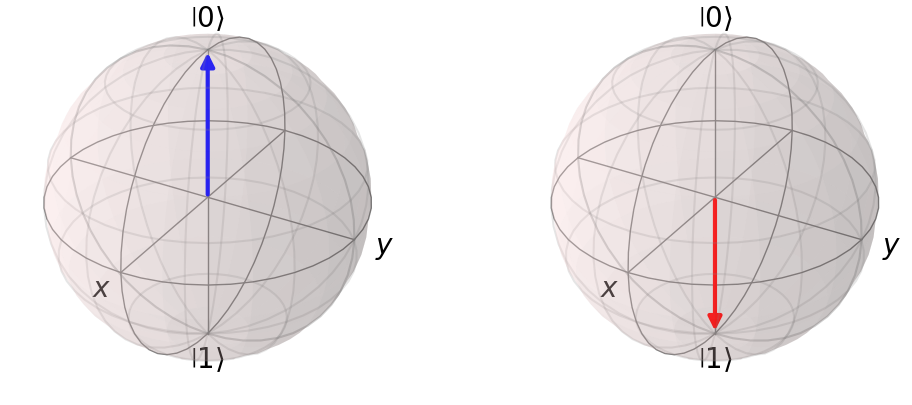

In [69]:
# ============================================================================
# BASIS STATES WITH BLOCH SPHERES
# ============================================================================

ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)

print("|0⟩ =", ket0)
print("|1⟩ =", ket1)

# Create figure with two Bloch spheres side by side
fig = plt.figure(figsize=(12, 5))

# Left plot: |0⟩ (North Pole)
ax1 = fig.add_subplot(121, projection='3d')
bloch0 = qt.Bloch(fig=fig, axes=ax1)
bloch0.add_states(qt.ket2dm(qt.basis(2, 0)))
bloch0.vector_color = ['blue']
bloch0.title = "|0⟩ (North Pole)"
bloch0.render()

# Right plot: |1⟩ (South Pole)
ax2 = fig.add_subplot(122, projection='3d')
bloch1 = qt.Bloch(fig=fig, axes=ax2)
bloch1.add_states(qt.ket2dm(qt.basis(2, 1)))
bloch1.vector_color = ['red']
bloch1.title = "|1⟩ (South Pole)"
bloch1.render()

## 2. Dirac Notation (Bra-Ket)

### Definitions

Let |ψ⟩ = (α, β)^T and |φ⟩ = (γ, δ)^T, where α, β, γ, δ ∈ C.

| Symbol | Name | Meaning |
|--------|------|---------|
| \|ψ⟩ | Ket | Column vector |
| ⟨ψ\| | Bra | Row vector, conjugate transpose |
| ⟨φ\|ψ⟩ | Inner product | Sum of φ_i* ψ_i |
| \|ψ⟩⟨φ\| | Outer product | Matrix |

### Important Notes

* denotes complex conjugation: if α = a + ib, then α* = a - ib
Inner product result is a complex number
Outer product result is a matrix

### Inner Product Properties

1. Linearity: ⟨ψ| (a|φ⟩ + b|χ⟩) = a⟨ψ|φ⟩ + b⟨ψ|χ⟩
2. Conjugate symmetry: ⟨ψ|φ⟩ = ⟨φ|ψ⟩*
3. Positive definiteness: ⟨ψ|ψ⟩ ≥ 0, equality iff |ψ⟩ = 0
4. Norm: || |ψ⟩ || = √⟨ψ|ψ⟩

### Orthonormality

For computational basis:
- ⟨0|0⟩ = 1
- ⟨1|1⟩ = 1
- ⟨0|1⟩ = 0
- ⟨1|0⟩ = 0

In [70]:
# ============================================================================
# BRA AND INNER PRODUCT FUNCTIONS
# ============================================================================

def bra(ket):
    """Return the bra (conjugate transpose) of a ket vector."""
    return np.conjugate(ket.T)

def inner(bra_vec, ket_vec):
    """Return the inner product ⟨bra|ket⟩."""
    return np.dot(bra_vec, ket_vec)

def outer(ket1, ket2):
    """Return the outer product |ket1⟩⟨ket2|."""
    return np.outer(ket1, bra(ket2))

print("=" * 60)
print("INNER PRODUCT VERIFICATION")
print("=" * 60)

print(f"<0|0> = {inner(bra(ket0), ket0)}")
print(f"<0|1> = {inner(bra(ket0), ket1)}")
print(f"<1|1> = {inner(bra(ket1), ket1)}")

print("\n" + "=" * 60)
print("CONJUGATE SYMMETRY TEST")
print("=" * 60)

inner_01 = inner(bra(ket0), ket1)
inner_10 = inner(bra(ket1), ket0)

print(f"<0|1> = {inner_01}")
print(f"<1|0> = {inner_10}")
print(f"<1|0>* = {np.conjugate(inner_10)}")
print(f"<0|1> == <1|0>* ? {np.isclose(inner_01, np.conjugate(inner_10))}")

print("\n" + "=" * 60)
print("OUTER PRODUCT EXAMPLES")
print("=" * 60)

P0 = outer(ket0, ket0)
P1 = outer(ket1, ket1)

print("P0 = |0><0| =")
print(P0)
print("\nP1 = |1><1| =")
print(P1)

print("\n" + "=" * 60)
print("RESOLUTION OF IDENTITY")
print("=" * 60)

identity = P0 + P1
print("P0 + P1 =")
print(identity)
print(f"Is this the identity matrix? {np.allclose(identity, np.eye(2))}")

print("\n" + "=" * 60)
print("VERIFICATION COMPLETE")
print("=" * 60)

INNER PRODUCT VERIFICATION
<0|0> = (1+0j)
<0|1> = 0j
<1|1> = (1+0j)

CONJUGATE SYMMETRY TEST
<0|1> = 0j
<1|0> = 0j
<1|0>* = -0j
<0|1> == <1|0>* ? True

OUTER PRODUCT EXAMPLES
P0 = |0><0| =
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

P1 = |1><1| =
[[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

RESOLUTION OF IDENTITY
P0 + P1 =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Is this the identity matrix? True

VERIFICATION COMPLETE


## 3. Positive Definiteness

### The Statement

For any vector |ψ⟩: ⟨ψ|ψ⟩ ≥ 0, and ⟨ψ|ψ⟩ = 0 if and only if |ψ⟩ is the zero vector.

> **Important:** The basis state |0⟩ is NOT the zero vector.

| Object | Representation | Inner Product | Valid State? |
|--------|----------------|----------------|--------------|
| \|0⟩ (basis state) | (1, 0)<sup>T</sup> | 1 | Yes |
| Zero vector | (0, 0)<sup>T</sup> | 0 | No |

Where:

|0⟩ = (1, 0)^T and ⟨0|0⟩ = 1

Zero vector = (0, 0)^T and ⟨0|0⟩ = 0

### Why ⟨ψ|ψ⟩ ≥ 0?

For |ψ⟩ = (α, β)^T = (a+ib, c+id)^T:

⟨ψ|ψ⟩ = |α|^2 + |β|^2 = (a^2 + b^2) + (c^2 + d^2) ≥ 0

### Visual Intuition (2D Euclidean Vectors)

| Vector | Length Squared | Interpretation |
|--------|----------------|----------------|
| (1, 1) | 2 | Positive length |
| (0, 0) | 0 | Zero vector only |
| (-1, 1) | 2 | Positive (length ignores direction) |
| (a, b) | a^2 + b^2 | Always ≥ 0 |

### Key Takeaway

|0⟩ is a valid quantum state (north pole of Bloch sphere). The zero vector is not a physical state.

## 4. Superposition and Normalization

### Definition

|ψ⟩ = α|0⟩ + β|1⟩, with α, β ∈ C

### Normalization Condition

⟨ψ|ψ⟩ = |α|^2 + |β|^2 = 1


### Key Insight

The relative phase e^{iφ} determines the azimuthal angle φ on the Bloch sphere. All states above have equal probability (0.5) of being measured as |0⟩ or |1⟩ because |α|^2 = |β|^2 = 0.5.

SUPERPOSITION STATES
|+⟩ = [0.7071+0.j 0.7071+0.j]
|-⟩ = [ 0.7071+0.j -0.7071+0.j]
|L⟩ = [0.7071+0.j     0.    +0.7071j]
|R⟩ = [0.7071+0.j     0.    -0.7071j]

NORMALIZATION VERIFICATION
|+⟩: ⟨ψ|ψ⟩ = 1.0000+0.0000j
|-⟩: ⟨ψ|ψ⟩ = 1.0000+0.0000j
|L⟩: ⟨ψ|ψ⟩ = 1.0000+0.0000j
|R⟩: ⟨ψ|ψ⟩ = 1.0000+0.0000j

BLOCH SPHERE VISUALIZATIONS


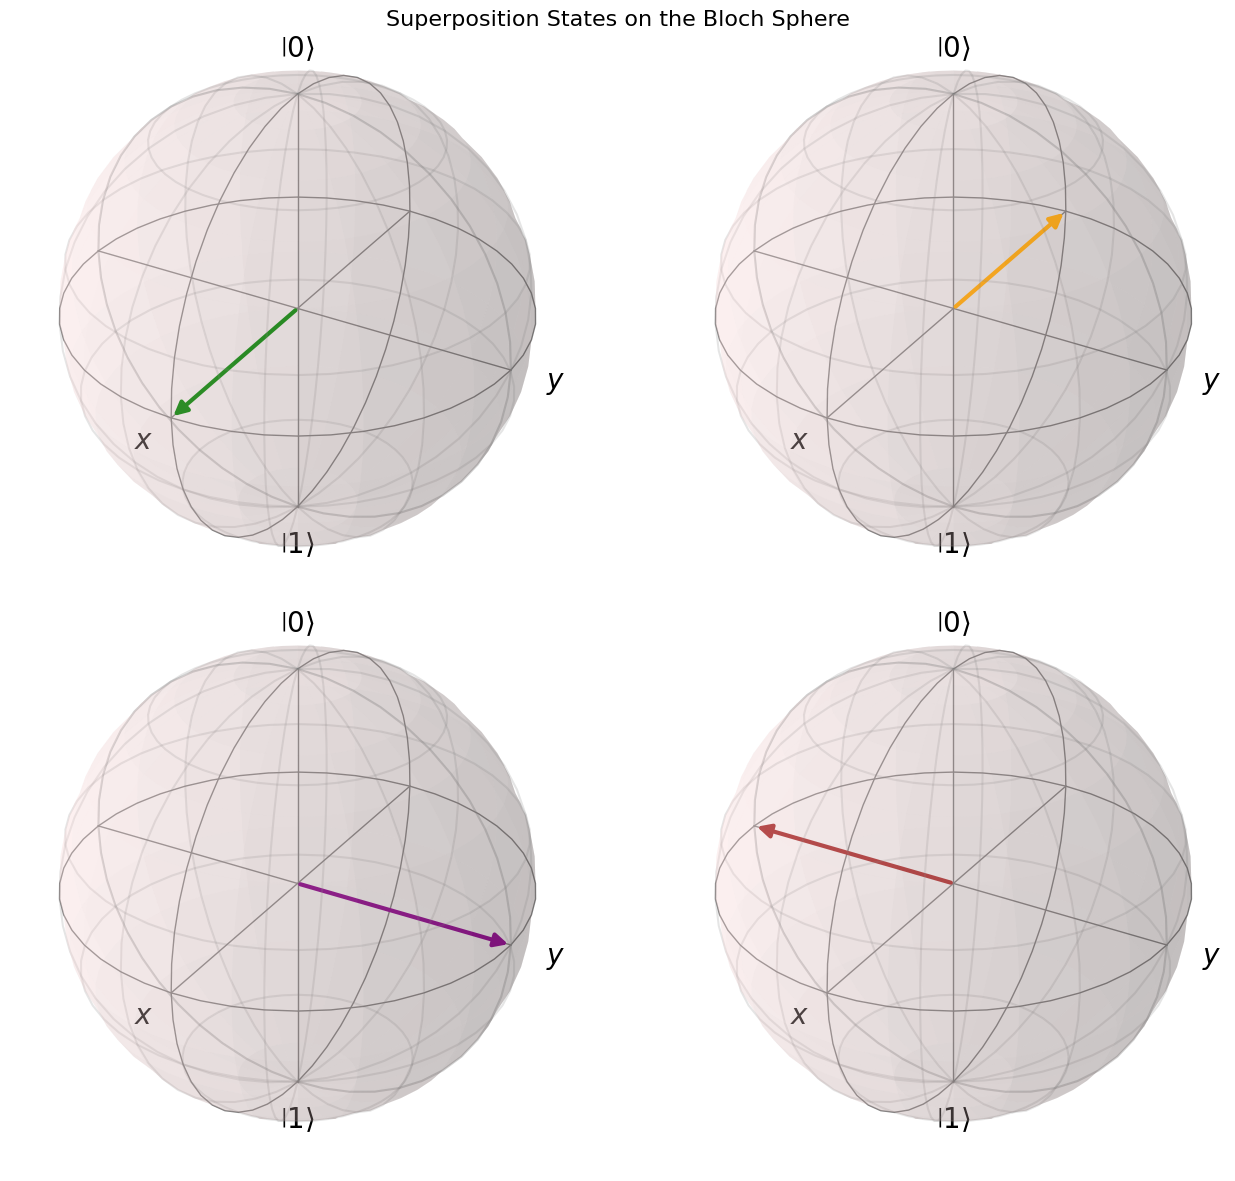


SUMMARY OF SUPERPOSITION STATES
|+⟩  = (|0⟩ + |1⟩)/√2   -> Equator (+X axis)   -> Phase φ = 0
|-⟩  = (|0⟩ - |1⟩)/√2   -> Equator (-X axis)   -> Phase φ = π
|L⟩  = (|0⟩ + i|1⟩)/√2  -> Equator (+Y axis)   -> Phase φ = π/2
|R⟩  = (|0⟩ - i|1⟩)/√2  -> Equator (-Y axis)   -> Phase φ = 3π/2

Key Insight: All states have |α|^2 = |β|^2 = 0.5 -> z = 0 (equator)
The relative phase e^{iφ} determines the azimuthal angle φ.


In [71]:
# ============================================================================
# CREATE AND VERIFY SUPERPOSITION STATES
# ============================================================================

alpha = 1 / np.sqrt(2)
beta = 1 / np.sqrt(2)

psi_plus = alpha * ket0 + beta * ket1
psi_minus = alpha * ket0 - beta * ket1
psi_left = alpha * ket0 + 1j * beta * ket1
psi_right = alpha * ket0 - 1j * beta * ket1

print("=" * 60)
print("SUPERPOSITION STATES")
print("=" * 60)

print("|+⟩ =", psi_plus)
print("|-⟩ =", psi_minus)
print("|L⟩ =", psi_left)
print("|R⟩ =", psi_right)

print("\n" + "=" * 60)
print("NORMALIZATION VERIFICATION")
print("=" * 60)

states = [("|+⟩", psi_plus), ("|-⟩", psi_minus), ("|L⟩", psi_left), ("|R⟩", psi_right)]

for name, state in states:
    norm_sq = inner(bra(state), state)
    print(f"{name}: ⟨ψ|ψ⟩ = {norm_sq:.4f}")

print("\n" + "=" * 60)
print("BLOCH SPHERE VISUALIZATIONS")
print("=" * 60)

# Create 2x2 grid of Bloch spheres
fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw={'projection': '3d'})

# Convert numpy arrays to QuTiP states
psi_plus_q = qt.Qobj(psi_plus).unit()
psi_minus_q = qt.Qobj(psi_minus).unit()
psi_left_q = qt.Qobj(psi_left).unit()
psi_right_q = qt.Qobj(psi_right).unit()

# Plot 1: |+⟩ (Top Left)
bloch_plus = qt.Bloch(fig=fig, axes=axes[0, 0])
bloch_plus.add_states(psi_plus_q)
bloch_plus.vector_color = ['green']
bloch_plus.title = "|+⟩"
bloch_plus.render()

# Plot 2: |-⟩ (Top Right)
bloch_minus = qt.Bloch(fig=fig, axes=axes[0, 1])
bloch_minus.add_states(psi_minus_q)
bloch_minus.vector_color = ['orange']
bloch_minus.title = "|-⟩"
bloch_minus.render()

# Plot 3: |L⟩ (Bottom Left)
bloch_left = qt.Bloch(fig=fig, axes=axes[1, 0])
bloch_left.add_states(psi_left_q)
bloch_left.vector_color = ['purple']
bloch_left.title = "|L⟩"
bloch_left.render()

# Plot 4: |R⟩ (Bottom Right)
bloch_right = qt.Bloch(fig=fig, axes=axes[1, 1])
bloch_right.add_states(psi_right_q)
bloch_right.vector_color = ['brown']
bloch_right.title = "|R⟩"
bloch_right.render()

plt.suptitle("Superposition States on the Bloch Sphere", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("SUMMARY OF SUPERPOSITION STATES")
print("=" * 60)
print("|+⟩  = (|0⟩ + |1⟩)/√2   -> Equator (+X axis)   -> Phase φ = 0")
print("|-⟩  = (|0⟩ - |1⟩)/√2   -> Equator (-X axis)   -> Phase φ = π")
print("|L⟩  = (|0⟩ + i|1⟩)/√2  -> Equator (+Y axis)   -> Phase φ = π/2")
print("|R⟩  = (|0⟩ - i|1⟩)/√2  -> Equator (-Y axis)   -> Phase φ = 3π/2")
print("\nKey Insight: All states have |α|^2 = |β|^2 = 0.5 -> z = 0 (equator)")
print("The relative phase e^{iφ} determines the azimuthal angle φ.")
print("=" * 60)

## 5. Outer Products and Projection Operators

The outer product |ψ⟩⟨φ| produces a matrix. When |φ⟩ = |ψ⟩, it is a projector:

P_ψ = |ψ⟩⟨ψ|

### Properties

| Property | Condition | Meaning |
|----------|-----------|---------|
| Idempotent | P^2 = P | Applying twice is same as once |
| Hermitian | P† = P | Matrix equals conjugate transpose |

### Computational Basis Projectors

P0 = |0⟩⟨0| = [[1, 0], [0, 0]]
P1 = |1⟩⟨1| = [[0, 0], [0, 1]]

Resolution of identity: P0 + P1 = I = [[1, 0], [0, 1]]

### Geometric Interpretation

P0|ψ⟩ = α|0⟩

Probability of measuring |0⟩ = ⟨ψ|P0|ψ⟩ = |α|^2

PROJECTOR PROPERTIES
P0^2 = P0? True
P1^2 = P1? True
P0† = P0? True
P1† = P1? True

MEASUREMENT PROBABILITIES FOR |+⟩
P(0) = ⟨+|P0|+⟩ = 0.500+0.000j
P(1) = ⟨+|P1|+⟩ = 0.500+0.000j
Sum = 1.000+0.000j

PROJECTION VISUALIZATION


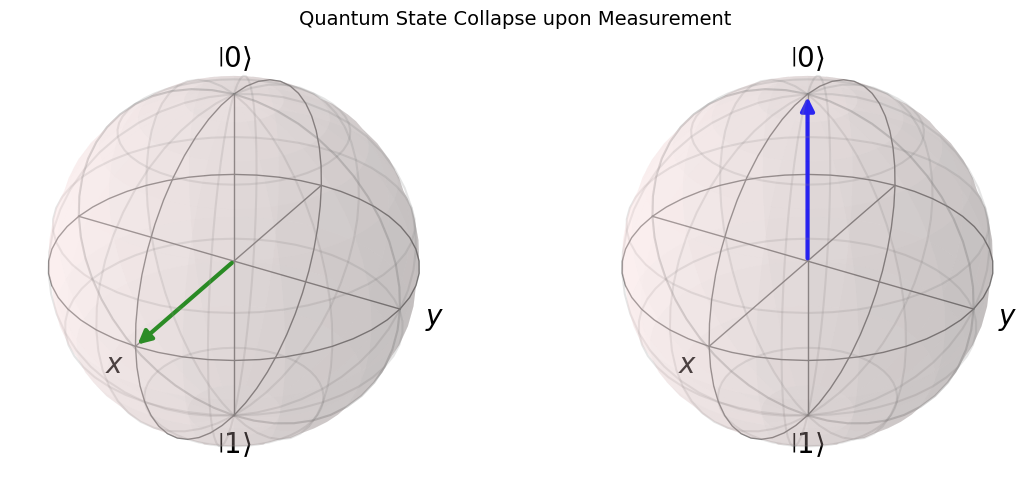


VERIFICATION COMPLETE


In [72]:
# ============================================================================
# PROJECTOR PROPERTIES AND MEASUREMENT SIMULATION
# ============================================================================

print("=" * 60)
print("PROJECTOR PROPERTIES")
print("=" * 60)

P0 = outer(ket0, ket0)
P1 = outer(ket1, ket1)

P0_sq = P0 @ P0
P1_sq = P1 @ P1

print("P0^2 = P0?", np.allclose(P0_sq, P0))
print("P1^2 = P1?", np.allclose(P1_sq, P1))

P0_dag = np.conjugate(P0.T)
P1_dag = np.conjugate(P1.T)

print("P0† = P0?", np.allclose(P0_dag, P0))
print("P1† = P1?", np.allclose(P1_dag, P1))

print("\n" + "=" * 60)
print("MEASUREMENT PROBABILITIES FOR |+⟩")
print("=" * 60)

prob_0 = inner(bra(psi_plus), P0 @ psi_plus)
prob_1 = inner(bra(psi_plus), P1 @ psi_plus)

print(f"P(0) = ⟨+|P0|+⟩ = {prob_0:.3f}")
print(f"P(1) = ⟨+|P1|+⟩ = {prob_1:.3f}")
print(f"Sum = {prob_0 + prob_1:.3f}")

print("\n" + "=" * 60)
print("PROJECTION VISUALIZATION")
print("=" * 60)

# Visualize projection of |+⟩ onto |0⟩
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': '3d'})

# Before measurement: |+⟩
bloch_before = qt.Bloch(fig=fig, axes=axes[0])
bloch_before.add_states(psi_plus_q)
bloch_before.vector_color = ['green']
bloch_before.title = "Before: |+⟩"
bloch_before.render()

# After measurement (collapsed to |0⟩)
bloch_after = qt.Bloch(fig=fig, axes=axes[1])
bloch_after.add_states(qt.basis(2, 0))
bloch_after.vector_color = ['blue']
bloch_after.title = "After: |0⟩ (with prob 0.5)"
bloch_after.render()

plt.suptitle("Quantum State Collapse upon Measurement", fontsize=14)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("VERIFICATION COMPLETE")
print("=" * 60)

## 6. Summary

### Key Concepts

| Concept | Python Implementation |
|---------|----------------------|
| Ket (state vector) | np.array([alpha, beta]) |
| Bra (dual vector) | np.conjugate(ket.T) |
| Inner product | np.dot(bra(phi), ket(psi)) |
| Outer product | np.outer(ket1, bra(ket2)) |
| Projector | np.outer(psi, bra(psi)) |
| Norm | np.sqrt(inner(bra(psi), psi)) |

### Important Formulas

⟨ψ|ψ⟩ = |α|^2 + |β|^2 = 1

P(0) = |⟨0|ψ⟩|^2 = |α|^2

|0⟩⟨0| + |1⟩⟨1| = I

### Visualization Summary

| State | Location | Coordinates | Overlap with Zero |
|-------|----------|-------------|-------------------|
| \|0⟩ | North Pole | (0, 0, 1) | 1 |
| \|1⟩ | South Pole | (0, 0, -1) | 0 |
| \|+⟩ | Equator (+X) | (1, 0, 0) | 0.5 |
| \|-⟩ | Equator (-X) | (-1, 0, 0) | 0.5 |
| \|L⟩ | Equator (+Y) | (0, 1, 0) | 0.5 |
| \|R⟩ | Equator (-Y) | (0, -1, 0) | 0.5 |

### Key Takeaways

1. Dirac notation is the language of quantum mechanics.
2. The inner product measures overlap between states.
3. The outer product creates operators (matrices) from states.
4. Projectors represent quantum measurements.
5. The Bloch sphere provides geometric visualization.
6. |0⟩ is not the zero vector.

---

**Day 1 Complete!** 🎉

Proceed to Day 2 when ready.